### Лабораторная работа №4 по ТМО

#### Линейные модели, SVM и деревья решений.

Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений

Задание:

1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие модели:

    + одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
    + SVM;
    + дерево решений.

5. Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
6. Постройте график, показывающий важность признаков в дереве решений.
7. Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

В качестве исходного датасета возьму __Student Productivity & Digital Distraction Dataset__ - https://www.kaggle.com/datasets/sehaj1104/student-productivity-and-digital-distraction-dataset

Этот набор данных посвящён студенческой успеваемости. Он содержит 20 000 записей о студентах, отражающих их образ жизни, академическое поведение, цифровые отвлекающие факторы и показатели продуктивности.

Он предназначен для анализа того, как современные цифровые привычки, такие как использование телефонов, социальных сетей и игр, влияют на продуктивность и успеваемость.

В этом датасете следующие столбцы:

+ **student_id** - ID для каждого студента (удалим позже);
+ **age** - возраст студента;
+ **gender** - пол студента (Male, Female, Other (лучше удалить))
+ **study_hours_per_day** - Среднее количество часов, затрачиваемых на учебу в день.
+ **sleep_hours** - Среднее количество часов сна в сутки
+ **phone_usage_hours** - Среднее количество часов, проводимых за телефоном ежедневно.
+ **social_media_hours** - Ежедневное время, проводимое в социальных сетях
+ **youtube_hours** - Ежедневное время, проведенное за просмотром YouTube
+ **gaming_hours** - Ежедневное время, проведенное за играми
+ **breaks_per_day** - Количество перерывов, сделанных во время учебных занятий.
+ **coffee_intake_mg** - Количество выпиваемого кофе
+ **exercise_minutes** - время учёбы в минутах
+ **assignments_completed** - число завершенных заданий
+ **attendance_percentage** - процент посещаемости
+ **stress_level** - уровень стресса (1-10)
+ **focus_score** - Оценка заинтересованности студентов (0–100)
+ **final_grade** - оценка учебной успеваемости
+ **productivity_score** - оценка продуктивности (0 - 100) - целевая переменная

Первым делом загрузим датасет и убедимся, что нет пропусков (при необходимости удалим пропуски), затем посмотрим на список столбцов и их типы.

In [ ]:
# добавим необходимые модули
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
students_origin = pd.read_csv("./student_productivity_distraction_dataset_20000.csv")

students_origin.head(10)

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
5,6,29,Other,7.18,3.52,4.02,3.74,1.42,0.16,10,392,12,3,47.58,10,70,59.48,47.31
6,7,21,Female,9.06,6.36,11.45,5.99,2.20,4.44,14,87,28,15,43.50,8,35,62.71,41.23
7,8,23,Female,6.37,4.86,3.31,1.37,4.36,5.13,2,152,103,17,75.22,6,59,52.22,53.81
8,9,26,Male,4.19,4.87,9.66,2.87,0.10,3.38,13,460,42,11,44.79,3,39,76.15,25.99
9,10,19,Female,7.28,9.56,2.13,0.81,1.35,2.55,7,416,107,6,79.15,10,73,88.53,73.18


In [3]:
print('Всего строк: {}'.format(students_origin.shape[0]))

print(f"\nВсего пропусков: {students_origin.isnull().sum().sum()}")

for i in list(students_origin.columns):
    print(i + "\t" + str(students_origin[i].isnull().sum()) + "\t" + str(round(students_origin[i].isnull().mean()*100, 2)) + "%")

Всего строк: 20000

Всего пропусков: 0
student_id	0	0.0%
age	0	0.0%
gender	0	0.0%
study_hours_per_day	0	0.0%
sleep_hours	0	0.0%
phone_usage_hours	0	0.0%
social_media_hours	0	0.0%
youtube_hours	0	0.0%
gaming_hours	0	0.0%
breaks_per_day	0	0.0%
coffee_intake_mg	0	0.0%
exercise_minutes	0	0.0%
assignments_completed	0	0.0%
attendance_percentage	0	0.0%
stress_level	0	0.0%
focus_score	0	0.0%
final_grade	0	0.0%
productivity_score	0	0.0%


In [4]:
print("Список колонок с типами данных: ")
students_origin.dtypes

Список колонок с типами данных: 


student_id                 int64
age                        int64
gender                       str
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

Так, пропусков не обнаружено, что радует, также видно, что большая часть данных уже приведена к целочисленному типу или типу с плавающей запятой. Одним словом, не нужно как-то предобрабатывать данные, разве что столбец Gender надо бы привести к True/False виду.

In [5]:
students_gend_cleared = students_origin[students_origin['gender'].isin(['Male', 'Female'])].copy()
students_gend_cleared['gender_bool'] = (students_gend_cleared['gender'] == 'Male')
students_gend_cleared = students_gend_cleared.drop(columns=['gender', 'student_id'])
# удалили заодно и student_id т.к ненужная переменная

print(f"Осталось строк: {len(students_gend_cleared)}")
print(students_gend_cleared['gender_bool'].value_counts())
print(students_gend_cleared[['gender_bool']].head())

Осталось строк: 19222
gender_bool
False    9640
True     9582
Name: count, dtype: int64
   gender_bool
0        False
1         True
2        False
3        False
4         True


Так, данные слегка предобработали и проверили, всё хорошо.

Теперь переходим к разделению на обучающую и тестовую выборки, после чего займёмся обучением моделей.

In [ ]:
#  Подготовка данных и разделение 

# Формируем признаки и целевую переменную
X = students_gend_cleared.drop(columns=['productivity_score'])  # убираем ID и target
y = students_gend_cleared['productivity_score']

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% данных на тест
    random_state=42,    # фиксированный seed для воспроизводимости
    shuffle=True        # перемешиваем перед разделением
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")


# ПУНКТ 4: Обучение моделей 

#  4.1 Линейная регрессия 
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print('finished linear')

#  4.2 SVM для регрессии (SVR) 
# Масштабируем признаки для SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)  
svr_model.fit(X_train_scaled, y_train)


# 4.3 Дерево решений 
tree_model = DecisionTreeRegressor(
    max_depth=10,           # ограничиваем глубину 
    min_samples_split=20,   # мин. количество образцов для разделения узла
    random_state=42         # для повторяемости
)
tree_model.fit(X_train, y_train)

print("\nВсе три модели успешно обучены!")

Обучающая выборка: 15377 строк
Тестовая выборка: 3845 строк
finished linear

Все три модели успешно обучены!


Модели обучены, теперь попробуем оценить их

In [7]:
# ПУНКТ 5: Оценка качества моделей

# Делаем предсказания на тестовой выборке
y_pred_linear = linear_model.predict(X_test)
y_pred_svr = svr_model.predict(X_test_scaled)  # для SVM — масштабированные данные
y_pred_tree = tree_model.predict(X_test)

# Считаем метрики
from sklearn.metrics import mean_absolute_error, r2_score

results = []

for name, y_pred in [
    ('Linear Regression', y_pred_linear),
    ('SVR', y_pred_svr),
    ('Decision Tree', y_pred_tree)
]:
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'R^2': r2})
    print(f"{name:20} | MAE: {mae:6.3f} | R^2: {r2:6.3f}")

Linear Regression    | MAE:  0.003 | R^2:  1.000
SVR                  | MAE:  0.314 | R^2:  0.999
Decision Tree        | MAE:  4.019 | R^2:  0.905


Так, у нас проблемы! модели оказались слишком переобучены. Похоже, имеет место синтетическая природа данных в датасете (хотя в описании датасета об этом ни слова)

Вероятно, имеет место формула, по которой рассчитывается рейтинг успеваемости, так что попробуем создать новые модели и взять в качестве целевой переменной не productivity_score, а final_grade.

In [8]:
#  Подготовка данных и разделение 

Xfg = students_gend_cleared.drop(columns=['final_grade', 'productivity_score'])
yfg = students_gend_cleared['final_grade']

Xfg_train, Xfg_test, yfg_train, yfg_test = train_test_split(
    Xfg, yfg, 
    test_size=0.2,      
    random_state=42,    
    shuffle=True        
)

# Исправлены имена переменных
print(f"Обучающая выборка: {Xfg_train.shape[0]} строк")
print(f"Тестовая выборка: {Xfg_test.shape[0]} строк")


#4. Обучение моделей 

# 4.1 Линейная регрессия
linear_model = LinearRegression()
linear_model.fit(Xfg_train, yfg_train)

# 4.2 SVM (SVR)
scaler = StandardScaler()
Xfg_train_scaled = scaler.fit_transform(Xfg_train)
Xfg_test_scaled = scaler.transform(Xfg_test)

svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(Xfg_train_scaled, yfg_train)

# 4.3 Дерево решений
tree_model = DecisionTreeRegressor(
    max_depth=10,           
    min_samples_split=20,   
    random_state=42
)
tree_model.fit(Xfg_train, yfg_train)

print("\nВсе три модели успешно обучены!")


#  5. Оценка качества моделей 

yfg_pred_linear = linear_model.predict(Xfg_test)
yfg_pred_svr = svr_model.predict(Xfg_test_scaled)
yfg_pred_tree = tree_model.predict(Xfg_test)

results = []
for name, y_pred in [
    ('Linear Regression', yfg_pred_linear),
    ('SVR', yfg_pred_svr),
    ('Decision Tree', yfg_pred_tree)
]:
    mae = mean_absolute_error(yfg_test, y_pred)
    r2 = r2_score(yfg_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'R^2': r2})
    print(f"{name:20} | MAE: {mae:6.3f} | R^2: {r2:6.3f}")

Обучающая выборка: 15377 строк
Тестовая выборка: 3845 строк

Все три модели успешно обучены!
Linear Regression    | MAE: 14.980 | R^2:  0.000
SVR                  | MAE: 16.251 | R^2: -0.256
Decision Tree        | MAE: 15.514 | R^2: -0.102


По итогу получилась и вовсе какая-то ерунда. Вероятно, корелляция между признаками и final_grade отсутствует напрочь ~~прямо как в жизни~~

В общем, будем работать с предыдущим результатом для productivity_score. Полученные метрики (R^2 = 1.0, MAE ~= 0) обусловлены синтетической природой датасета: целевая переменная productivity_score, вероятно, генерировалась как линейная комбинация исходных признаков. Линейная регрессия точно восстановила скрытую формулу, тогда как SVR и дерево решений показали чуть большие ошибки из-за регуляризации и дискретного характера разбиений. Для задач машинного обучения такие датасеты полезны для отладки пайплайна, но в реальных условиях метрики будут ниже из-за шума и нелинейных зависимостей.

В общем, в следующей лабе возьмём другой датасет, а здесь пока вернёмся к productivity_score и перейдём к визуализациям

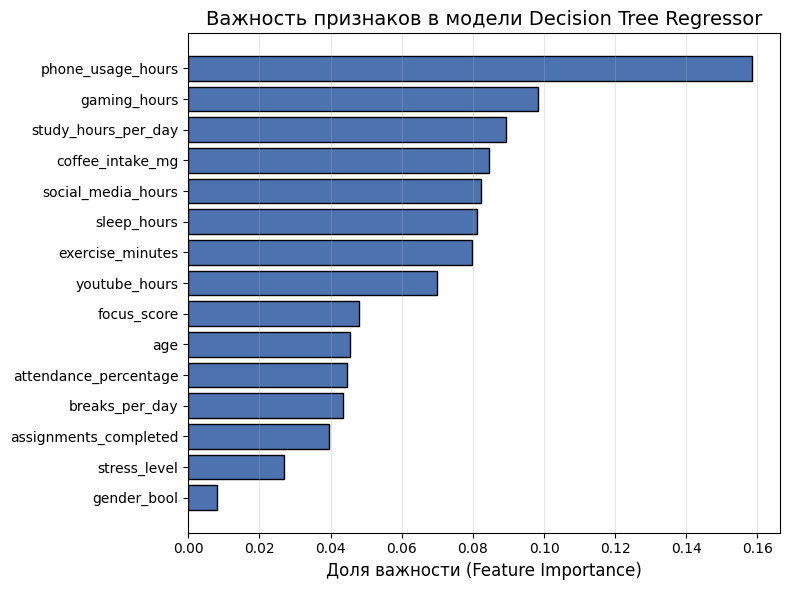

In [12]:
# ПУНКТ 6: Важность признаков в дереве решений

# Получаем важность и имена признаков
importances = tree_model.feature_importances_
feature_names = Xfg_train.columns  # X был определён ранее: students_gend_cleared.drop(columns=['productivity_score'])

# Формируем DataFrame для удобной сортировки
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values('Важность', ascending=True)

# Строим горизонтальный barplot
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Признак'], importance_df['Важность'], color='#4C72B0', edgecolor='black')
plt.xlabel('Доля важности (Feature Importance)', fontsize=12)
plt.title('Важность признаков в модели Decision Tree Regressor', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Теперь наглядно видно, что productivity_score был создан искусственно

Правила дерева решений (первые 3 уровня):
|--- gaming_hours <= 0.36
|   |--- focus_score <= 91.50
|   |   |--- youtube_hours <= 0.52
|   |   |   |--- focus_score <= 32.50
|   |   |   |   |--- value: [86.42]
|   |   |   |--- focus_score >  32.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- youtube_hours >  0.52
|   |   |   |--- social_media_hours <= 7.89
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- social_media_hours >  7.89
|   |   |   |   |--- value: [55.71]
|   |--- focus_score >  91.50
|   |   |--- stress_level <= 5.50
|   |   |   |--- phone_usage_hours <= 9.40
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- phone_usage_hours >  9.40
|   |   |   |   |--- value: [51.91]
|   |   |--- stress_level >  5.50
|   |   |   |--- attendance_percentage <= 98.54
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- attendance_percentage >  98.54
|   |   |   |   |--- value: [43.63]
|--- gaming_hours >  0.36
|   |--- stress_level 

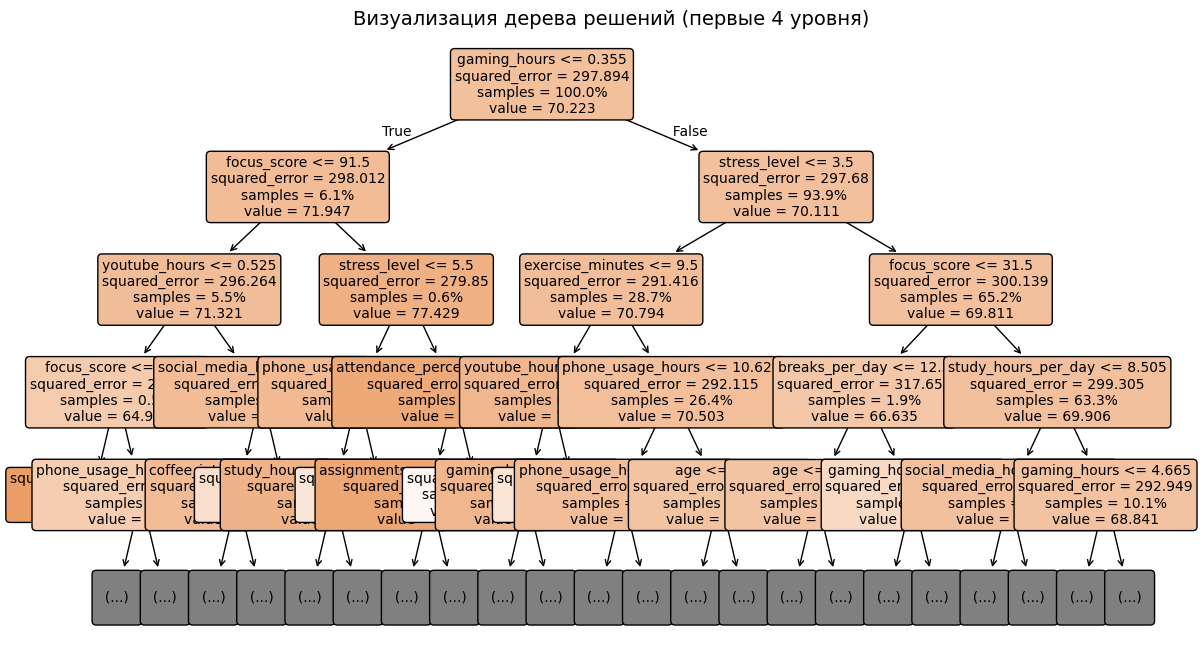

In [17]:
#  ПУНКТ 7: Визуализация и правила дерева 

from sklearn.tree import export_text, plot_tree

# Текстовые правила 
print("Правила дерева решений (первые 3 уровня):")
rules_text = export_text(
    tree_model, 
    feature_names=list(Xfg_train.columns), 
    max_depth=3  # ограничиваем глубину для читаемости
)
print(rules_text)

# Графическая визуализация 
plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    feature_names=Xfg_train.columns,
    filled=True,          # заливка узлов цветом
    rounded=True,         # скруглённые углы
    fontsize=10,
    max_depth=4,          # показываем только первые 4 уровня
    proportion=True       # доля образцов в каждом узле
)
plt.title("Визуализация дерева решений (первые 4 уровня)", fontsize=14)
plt.show()